<a href="https://colab.research.google.com/github/andyotani/Machine-learning_26-27/blob/main/JS04/Tugas_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tugas Lab

### 1. Identifikasi variabel-variabel yang akan digunakan sebagai variabel bebas (fitur) dan variabel target (biaya medis personal).

Import library dan membaca dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Membaca dataset
df = pd.read_csv("insurance.csv")

# Melihat data
print(df.head())

# Informasi dataset
print("\nShape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nDeskripsi statistik:")
print(df.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Shape: (1338, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Deskripsi statistik:
               age          bmi     children

Dataset memiliki 1.338 data dan 7 kolom, yaitu age, sex, bmi, children, smoker, region, dan charges.

Identifikasi variabel

In [3]:
X = df.drop("charges", axis=1)
y = df["charges"]

print("Fitur:")
print(X.columns)

print("\nTarget:")
print(y.name)

Fitur:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

Target:
charges


Visualisasi data

Visualisasi yang relevan untuk melihat hubungan fitur dengan biaya medis:

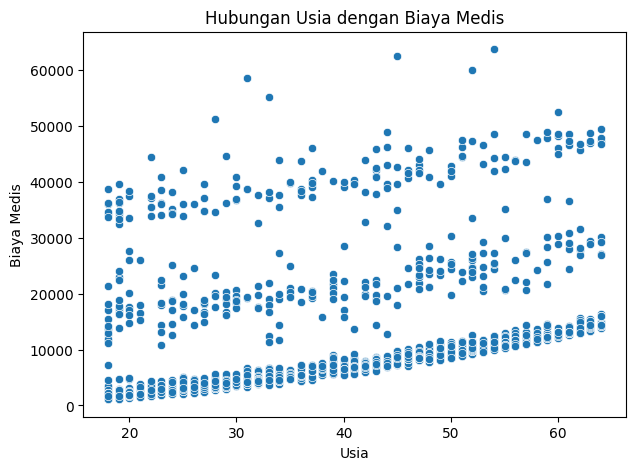

In [4]:
# Hubungan usia dengan biaya medis
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="age", y="charges")
plt.title("Hubungan Usia dengan Biaya Medis")
plt.xlabel("Usia")
plt.ylabel("Biaya Medis")
plt.show()

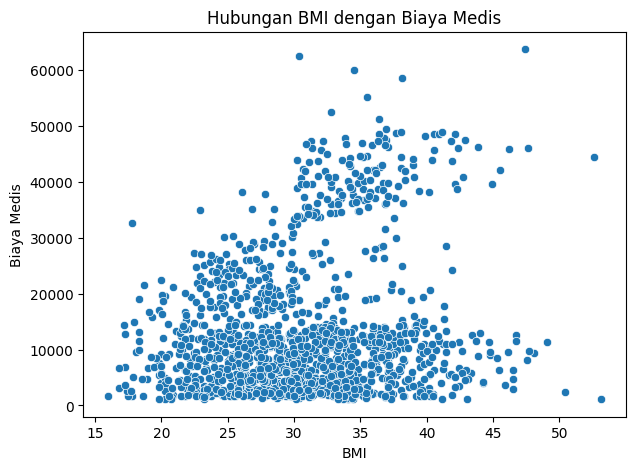

In [5]:
# Hubungan BMI dengan biaya medis
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="bmi", y="charges")
plt.title("Hubungan BMI dengan Biaya Medis")
plt.xlabel("BMI")
plt.ylabel("Biaya Medis")
plt.show()

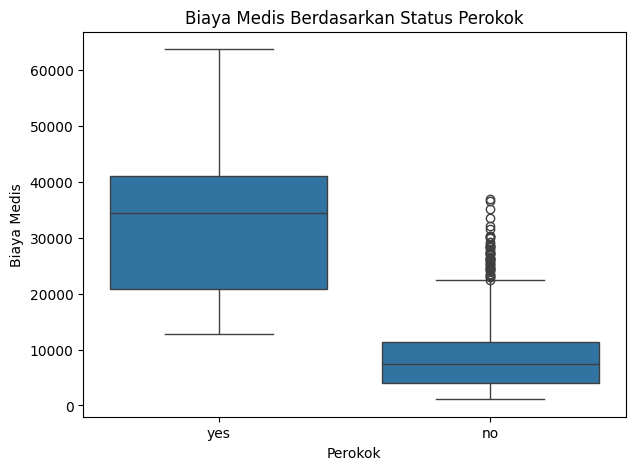

In [6]:
# Biaya medis berdasarkan status perokok
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Biaya Medis Berdasarkan Status Perokok")
plt.xlabel("Perokok")
plt.ylabel("Biaya Medis")
plt.show()

### 2. Bagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi yang sesuai.

Digunakan proporsi 70% data latih dan 30% data uji.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))

Jumlah data train: 936
Jumlah data test : 402


### 3. Lakukan feature scaling jika diperlukan.

  Karena terdapat variabel numerik dan kategorikal, preprocessing dilakukan dengan:

* StandardScaler untuk age, bmi, dan children
* OneHotEncoder untuk sex, smoker, dan region

In [8]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Scaling terutama diperlukan untuk SVR, karena SVR sensitif terhadap skala fitur.

### 4. Buat model multiple linear regression menggunakan Scikit-Learn.

### 5. Latih model pada data latih dan lakukan prediksi pada data uji.

### 6. Evaluasi model dengan menghitung metrik seperti R-squared, MSE, dan MAE. Tampilkan hasil evaluasi.


In [9]:
# Membuat pipeline Linear Regression
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Melatih model
linear_model.fit(X_train, y_train)

# Prediksi data test
y_pred_lr = linear_model.predict(X_test)

# Evaluasi
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=== MULTIPLE LINEAR REGRESSION ===")
print("R-squared :", r2_lr)
print("MSE       :", mse_lr)
print("MAE       :", mae_lr)

=== MULTIPLE LINEAR REGRESSION ===
R-squared : 0.769611805436901
MSE       : 33780509.57479166
MAE       : 4145.450555627599


Hasil pengujian pada dataset:

Metrik	Hasil
* R-squared	0.7696
* MSE	33,780,509.57
* MAE	4,145.45

Artinya, model Multiple Linear Regression memiliki nilai R² sekitar 0,77, sehingga model dapat menjelaskan sekitar 77% variasi biaya medis pada data uji.

Visualisasi Actual vs Predicted

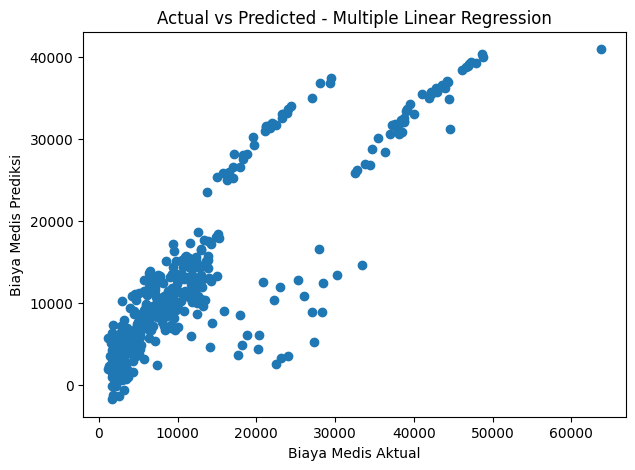

In [10]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Biaya Medis Aktual")
plt.ylabel("Biaya Medis Prediksi")
plt.title("Actual vs Predicted - Multiple Linear Regression")

plt.show()


### 7. Ulagi langkah 4 dengan menggunakan model SVR. Anda dapat bereksperimen dengan dengan melakukan hyperparameter tunning.

Pertama kita buat model SVR dengan kernel RBF.

In [11]:
svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR(kernel="rbf"))
    ]
)

# Training
svr_model.fit(X_train, y_train)

# Prediksi
y_pred_svr = svr_model.predict(X_test)

# Evaluasi
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("=== SVR ===")
print("R-squared :", r2_svr)
print("MSE       :", mse_svr)
print("MAE       :", mae_svr)

=== SVR ===
R-squared : -0.08015990878507506
MSE       : 158377699.04059398
MAE       : 8239.50730804069


Hyperparameter Tuning SVR

Kita dapat mencoba beberapa kombinasi C, gamma, dan epsilon.

In [12]:
param_grid = {
    "model__C": [1, 10, 100, 1000],
    "model__gamma": ["scale", 0.01, 0.1],
    "model__epsilon": [0.1, 0.2, 0.5]
}

grid_search = GridSearchCV(
    svr_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Parameter terbaik:")
print(grid_search.best_params_)

Parameter terbaik:
{'model__C': 1000, 'model__epsilon': 0.5, 'model__gamma': 'scale'}


Kemudian gunakan model terbaik:

In [13]:
best_svr = grid_search.best_estimator_

y_pred_svr_tuned = best_svr.predict(X_test)

r2_svr_tuned = r2_score(y_test, y_pred_svr_tuned)
mse_svr_tuned = mean_squared_error(y_test, y_pred_svr_tuned)
mae_svr_tuned = mean_absolute_error(y_test, y_pred_svr_tuned)

print("=== SVR SETELAH TUNING ===")
print("R-squared :", r2_svr_tuned)
print("MSE       :", mse_svr_tuned)
print("MAE       :", mae_svr_tuned)

=== SVR SETELAH TUNING ===
R-squared : 0.6575931306170527
MSE       : 50205170.241469085
MAE       : 3104.722479968838


## Kesimpulan

Berdasarkan hasil praktikum yang telah dilakukan, dapat disimpulkan bahwa proses prediksi biaya asuransi menggunakan metode **Multiple Linear Regression** dan **Support Vector Regression (SVR)** dapat dilakukan dengan tahapan preprocessing data, pembagian data menjadi data training dan testing, serta transformasi fitur numerik dan kategorikal menggunakan `StandardScaler`, `OneHotEncoder`, dan `ColumnTransformer`.

Pada **Multiple Linear Regression**, model dilatih menggunakan data training dan kemudian dievaluasi menggunakan data testing dengan metrik **R-squared (R²), Mean Squared Error (MSE), dan Mean Absolute Error (MAE)**. Hasil evaluasi menunjukkan kemampuan model dalam memprediksi biaya asuransi berdasarkan fitur-fitur yang tersedia pada dataset.

Selanjutnya, metode **Support Vector Regression (SVR)** dengan kernel RBF diterapkan untuk melakukan prediksi. Model SVR kemudian dilakukan **hyperparameter tuning menggunakan GridSearchCV** untuk memperoleh kombinasi parameter yang digunakan pada proses prediksi. Hasil evaluasi setelah tuning menunjukkan perubahan nilai R², MSE, dan MAE dibandingkan dengan model SVR sebelum tuning.

Dengan demikian, praktikum ini menunjukkan bahwa proses **preprocessing, pemodelan, evaluasi, dan optimasi hyperparameter** merupakan tahapan penting dalam membangun model regresi. Perbedaan nilai R², MSE, dan MAE pada setiap model menunjukkan adanya perbedaan hasil prediksi antara Multiple Linear Regression, SVR sebelum tuning, dan SVR setelah tuning. Pemilihan model dapat dilakukan berdasarkan hasil evaluasi yang diperoleh pada data testing.
